<a href="https://colab.research.google.com/github/a1ren-code/PyWGCNA/blob/main/Single_Cell_Transcriptomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring Cellular Heterogeneity with Seurat

Seurat is a R library for single-cell RNA-seq (scRNA-seq) data analysis. It is used to identify different cell types and cell states within samples. scRNA-seq analysis provides a better understanding of complex systems and/or more specialized cells, unlike bulk RNA-seq, which describes "average" expression levels across samples. [(Source)](https://www.babraham.ac.uk/blog/single-cell-sequencing)

We'll be using Seurat to analyze 2700 peripheral blood mononuclear cells. Most scRNA-seq datasets have 10s of thousands of cells, if not more, but that's beyond the time constraints of this workshop. Feel free to explore on your own time, though!

This notebook is an adapted version of [this tutorial](https://satijalab.org/seurat/articles/pbmc3k_tutorial).

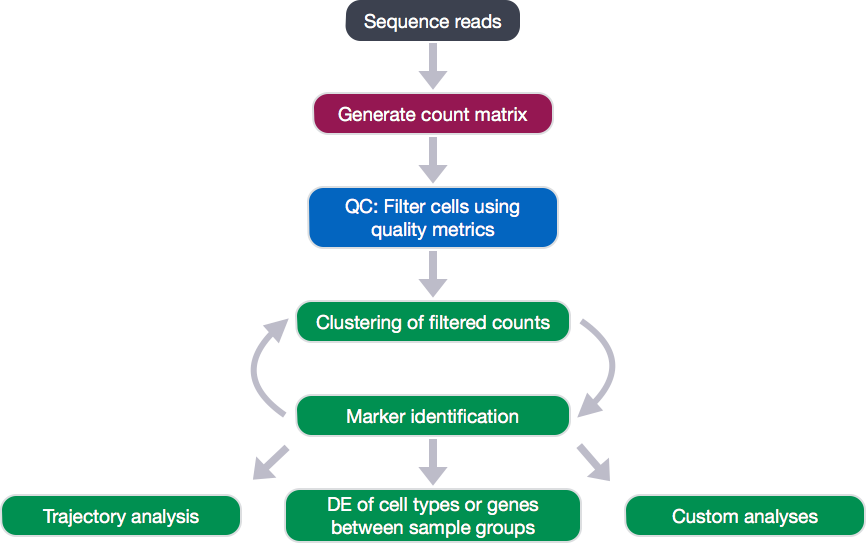

## Installing Packages and Loading Data


(Ignore any error messages it should work fine regardless)

In [ ]:
install.packages(c("dplyr", "Seurat", "patchwork", "devtools", "remotes"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘fs’


Warning message in install.packages(c("dplyr", "Seurat", "patchwork", "devtools", :
“installation of package ‘fs’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "Seurat", "patchwork", "devtools", :
“installation of package ‘devtools’ had non-zero exit status”


In [ ]:
library(dplyr)      # data manipulation
library(Seurat)     # scRNA-seq analysis
library(patchwork)  # graphic visualization
library(devtools)   # additional package installation tool
library(remotes)    # another package installation tool


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: usethis


Attaching package: ‘remotes’


The following objects are masked from ‘package:devtools’:

    dev_package_deps, github_pull, github_release, install_bioc,
    install_bitbucket, install_cran, install_deps, install_dev,
    install_git, install_github, install_gitlab, install_local,
    install_svn, install_url, install_version, update_packages




In [ ]:
# dataset package
devtools::install_github("satijalab/seurat-data")

Warning message:
“`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.”



Rcpp     (1.1.1 -> 1.1.1-1.1) [CRAN]
glue     (1.8.0 -> 1.8.1    ) [CRAN]
vctrs    (0.7.2 -> 0.7.3    ) [CRAN]
magrittr (2.0.4 -> 2.0.5    ) [CRAN]
fs       (2.0.1 -> 2.1.0    ) [CRAN]
xtable   (1.8-4 -> 1.8-8    ) [CRAN]
cpp11    (0.5.3 -> 0.5.4    ) [CRAN]
S7       (0.2.1 -> 0.2.2    ) [CRAN]
ggplot2  (4.0.2 -> 4.0.3    ) [CRAN]
openssl  (2.3.5 -> 2.4.0    ) [CRAN]
curl     (7.0.0 -> 7.1.0    ) [CRAN]
purrr    (1.2.1 -> 1.2.2    ) [CRAN]


Installing 12 packages: Rcpp, glue, vctrs, magrittr, fs, xtable, cpp11, S7, ggplot2, openssl, curl, purrr

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in i.p(...):
“installation of package ‘fs’ had non-zero exit status”


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp4LTTsW/remotes177471fe0de/satijalab-seurat-data-3e51f44/DESCRIPTION’ ... OK
* preparing ‘SeuratData’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘SeuratData_0.2.2.9002.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(SeuratData)

In [ ]:
AvailableData() # if you'd like to run this pipeline on another dataset, you can find sample data here!

,Dataset,Version,Summary,species,system,ncells,tech,seurat,default.dataset,disk.datasets,other.datasets,notes,Installed,InstalledVersion
,<chr>,<pckg_vrs>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<pckg_vrs>
adiposeref.SeuratData,adiposeref,1.0.0,Azimuth Reference: adipose,human,adipose,160075,scRNA-seq and sNuc-seq,NA,NA,NA,NA,NA,FALSE,NA
bmcite.SeuratData,bmcite,0.3.0,30k Bone Marrow Cells,human,bone marrow,30672,NA,3.2.2,NA,NA,NA,NA,FALSE,NA
bonemarrowref.SeuratData,bonemarrowref,1.0.0,Azimuth Reference: bonemarrow,human,bonemarrow,297627,10x v2,NA,NA,NA,NA,NA,FALSE,NA
cbmc.SeuratData,cbmc,3.1.4,scRNAseq and 13-antibody sequencing of CBMCs,human,CBMC (cord blood),8617,CITE-seq,3.1.4,raw,processed,NA,NA,FALSE,NA
celegans.embryo.SeuratData,celegans.embryo,0.1.0,6k C. elegans embryos from Packer and Zhu et al (2019),C. elegans,embryo,6188,NA,NA,raw,NA,NA,NA,FALSE,NA
fetusref.SeuratData,fetusref,1.0.0,Azimuth Reference: fetus,human,fetus,377456,NA,NA,NA,NA,NA,NA,FALSE,NA
hcabm40k.SeuratData,hcabm40k,3.0.0,"40,000 Cells From the Human Cell Atlas ICA Bone Marrow Dataset",human,bone marrow,40000,10x v2,NA,raw,NA,NA,NA,FALSE,NA
heartref.SeuratData,heartref,1.0.0,Azimuth Reference: heart,human,heart,656509,scRNA-seq and sNuc-seq,NA,NA,NA,NA,NA,FALSE,NA
humancortexref.SeuratData,humancortexref,1.0.0,Azimuth Reference: humancortex,human,motor cortex,76533,NA,NA,NA,NA,NA,NA,FALSE,NA


In [ ]:
# downloading the data and loading the Seurat object
InstallData("pbmc3k")
pbmc <- LoadData("pbmc3k")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Warning message:
“Assay RNA changing from Assay to Assay”
Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Validating object structure for Assay ‘RNA’

Object representation is consistent with the most current Seurat version

Warning message:
“Assay RNA changing from Assay to Assay5”


We can view the basic information about the Seurat object below. "Features" refer to the unique gene transcripts across the dataset. The "counts" layers refers to the count matrix, which tracks the number of RNA transcripts in each cell that correlates to each feature.

In [ ]:
pbmc

We can take a look at the count matrix data to see what we're working with:

Rows correspond to genes, and columns correspond to cells. The values in a cell indicate how many RNA transcripts of a gene are found in a particular cell. Since these matrices are pretty big, Seurat represents 0s as "."s to conserve memory.

In [ ]:
pbmc.data[c("CD3D", "TCL1A", "MS4A1"), 1:30]

## Quality Control and Filtering

We want to filter out cells that express too low (most likely an empty bead) or too many genes (most likely a doublet/multiplet - 2+ genes got stuck to one bead), since they'll most likely skew our downstream analysis. Additionally, we want to filter out stressed/dying cells, which can be detected because of their high mitochondrial gene expression.

In [ ]:
# adding a metadata column for the % mitochondrial expression
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")

In [ ]:
# visualizing the distribution of gene count, RNA transcript count, and % mitochondrial expression across the dataset
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [ ]:
# check the correlation between features in our dataset
plot1 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [ ]:
# filter out cells with too few/too many genes, too much mitochondrial expression
pbmc <- subset(pbmc, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)

## Normalizing Data

Cells often have varying sequence depth (number of times each base is sequenced). In other words, some cells may have better sequencing coverage than others, which may lead to biases in our downstream analysis of not addressed properly. Therefore, we need normalize the data so that the cells can be accurately compared to one another. We'll use the LogNormalize method, which divides the feature counts of each cell by the total transcript count and multiplies the result by a scale factor before applying a log transform (y=log(x)).



In [ ]:
pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)

# Variable Feature Identification

We'll now narrow our focus on genes that exhibit high variability among cells --- this will help us observe sources of differentiation among our samples. (Genes with relatively similar expression levels across cells won't be as useful for differentiation between cell identities.)

We'll be using the VST (Variance Stabilizing Transformation) method to calculate feature variance. VST involves taking the log values of variance and mean of the dataset features, then using LOESS (local polynomial regression) to fit a polynomial line to the aforementioned values. The feature counts for each gene and cell are then standardized (z-score) with the average feature count and expected variance. Once this is calculated, the feature variance for each feature is determined. The top 2000 features with the highest variance are selected as the variable features.

In [ ]:
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(pbmc), 10)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(pbmc)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1
plot2

## Scaling Data

For our downstream data, we will make the assumption that all of the features detected in our dataset are equally important. However, our dataset genes still have varied variance and average expression levels. To make this assumption valid, we will scale our data such that the average expression across all cells is 0 and the variance across the cells is 1.

In [ ]:
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)

## Dimensional Reduction
We're going to narrow our focus further by finding groups of genes (aka "metagenes") that best capture the variation in our dataset. This is accomplished through Principal Component Analysis. At a high level, Principal Component analysis works by reducing the dimensionality of our data by taking our existing features and compressing the information in those features into a smaller number of variables (aka Principal Components). The PCs represent gene modules that are either correlated or anticorrelated (inverse relationship between the original genes vs. the PC) across cells in the dataset.

In [ ]:
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))

In [ ]:
# visualize top genes associated with PCs - we'll look at PC 1 and 2
VizDimLoadings(pbmc, dims = 1:2, reduction = "pca")

In [ ]:
# visualize each cell's/gene's principal component score
DimHeatmap(pbmc, dims = 1, cells = 500, balanced = TRUE)

We can use an Elbow Plot to see the % variance captured by each principal component. The contributions of each PC somewhat taper off after PC 10, so we'll use that as a cutoff for our downstream analysis.

In [ ]:
ElbowPlot(pbmc)

We'll now cluster the cells in our dataset. FindNeighbors finds the 20 nearest neighboring cells with the most similar gene expression for each cell using the K-Nearest Neighbors Algorithm. FindClusters clusters cells based on each cells' shared nearest neighbors.

In [ ]:
pbmc <- FindNeighbors(pbmc, dims = 1:10)
pbmc <- FindClusters(pbmc, resolution = 0.5)

We can use RunUMAP to view these clusters in 2D space. UMAP is a dimensional reduction technique that "learns" the shape of the high-dimensionality dataset and captures the patterns of variation in a lower dimensionality space.

In [ ]:
pbmc <- RunUMAP(pbmc, dims = 1:10)
options(repr.plot.width = 7, repr.plot.height = 7)
DimPlot(pbmc, reduction = "umap", label = TRUE)

## Marker identification

Now that we've found the clusters in our dataset, we can look for what features define them. FindMarkers uses a Wilcoxon rank sum test to calculate the differential expression levels between two identity classes.

In [ ]:
# Finding markers that distinguish cluster 1 from the all of the other clusters combined
# Feel free to change ident.1 to any other ident (0-8)
# You can also define an additional identity with the ident.2 parameter to see how
# the two clusters differentiate from each other
cluster1.markers <- FindMarkers(pbmc, ident.1 = 1)
head(cluster1.markers, n = 5)

In [ ]:
# map the distribution of expression levels across different clusters
options(repr.plot.width = 15, repr.plot.height = 7)
VlnPlot(pbmc, features = c("S100A8", "LGALS2", "FCN1"))

In [ ]:
# see the expression levels at the cellular level
FeaturePlot(pbmc, features = c("S100A8", "LGALS2", "S100A9", "FCN1"))

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

In [ ]:
# plot the top positive markers with enriched expression for each cluster
options(repr.plot.width = 15, repr.plot.height = 15)
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10
DoHeatmap(pbmc, features = top10$gene) + NoLegend()

Lastly, we can annotate our clusters with experimentally determined markers to see the cell subtypes these clusters correlate to. The blood samples actually feature a diverse range of immune cells! Isn't it cool how computational methods can detect patterns in gene expression, group data points together through unsupervised learning, and characterize cell populations?!?!

In [ ]:
new.cluster.ids <- c("Naive CD4 T", "CD14+ Mono", "Memory CD4 T", "B", "CD8 T", "FCGR3A+ Mono",
    "NK", "DC", "Platelet")
names(new.cluster.ids) <- levels(pbmc)
pbmc <- RenameIdents(pbmc, new.cluster.ids)
DimPlot(pbmc, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()